# Hazardous emission detection — texel

Binary classification (hazardous vs. not hazardous) of single-gas presentations from `data/1_600_20`.

**Pipeline** (matches `run_classification_136_train_test.py` and the texel config from the *Continuous emission detection* notebooks):

1. Reduce to the 8 active sensors.
2. Expand to **136** features = raw + ∂¹ + ∂² (24) + 56 ratios + 56 differences.
3. Random HD projection `W_hd ∼ Bernoulli(p_hd)` and **top-k** sparsification.
4. Hebbian readout with `n_out = 2` neurons; the prediction is the argmax output neuron per frame.

**Class mapping (per user):**
- gas 1 (CO) → **hazardous** (class 0)
- gas 2 (Ethylene) → not hazardous (class 1)
- gas 3 (Methane) → not hazardous (class 1)

**Split:** first 450 presentations → train, last 150 → test. Frame-based accuracy reported for each.

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

from tools import load

## Load sequence and build labels

In [95]:
FILENAME       = '1_600_20_corrected'
N_TRAIN_SEQ    = 10      # first 450 presentations -> train
HAZARDOUS_GAS  = {1}      # CO is the only hazardous gas
GAS_NAMES      = {1: 'CO', 2: 'Ethylene', 3: 'Methane'}
CLASS_NAMES    = {0: 'hazardous', 1: 'not hazardous'}

sensor_data, sequence, times_sec, sequence_sec = load(FILENAME, reduced=True)
h = float(np.median(np.diff(times_sec)))
n_sensors = sensor_data.shape[1]
print(f'sensor_data: {sensor_data.shape}  h={h:.3f}s')
print(f'sequence: {len(sequence)} presentations, gases = {sorted({s[1] for s in sequence})}')
print(f'max inter-presentation gap: {np.diff(sequence_sec).max():.0f}s  '
      f'(continuous after gap correction)')

sensor_data: (11691, 8)  h=1.000s
sequence: 600 presentations, gases = [1, 2, 3]
max inter-presentation gap: 21s  (continuous after gap correction)


In [96]:
# Binary labels per frame: 0 -> hazardous, 1 -> not hazardous, -1 -> unlabeled (between presentations).
# Frame-level train / test masks based on the FIRST N_TRAIN_SEQ presentations.
y_frame    = -np.ones(len(times_sec), dtype=int)
train_mask = np.zeros(len(times_sec), dtype=bool)
test_mask  = np.zeros(len(times_sec), dtype=bool)

for i, (_, gas) in enumerate(sequence):
    if i + 1 < len(sequence_sec):
        flag = (times_sec > sequence_sec[i]) & (times_sec < sequence_sec[i + 1])
    else:
        flag = (times_sec > sequence_sec[i])
    y_frame[flag]    = 0 if int(gas) in HAZARDOUS_GAS else 1
    if i < N_TRAIN_SEQ:
        train_mask[flag] = True
    else:
        test_mask[flag]  = True

labeled = y_frame >= 0
train_mask &= labeled
test_mask  &= labeled

print(f'train frames: {train_mask.sum()}  ({(y_frame[train_mask] == 0).sum()} hazardous, '
      f'{(y_frame[train_mask] == 1).sum()} not hazardous)')
print(f'test  frames: {test_mask.sum()}  ({(y_frame[test_mask] == 0).sum()} hazardous, '
      f'{(y_frame[test_mask] == 1).sum()} not hazardous)')

train frames: 190  (38 hazardous, 152 not hazardous)
test  frames: 11202  (3759 hazardous, 7443 not hazardous)


## Sensor trace expansion (∂¹+∂² + 56R + 56D = 136)

In [97]:
def backward_diff_array(y, h, n):
    coeffs = np.array([(-1) ** kk * comb(n, kk) for kk in range(n + 1)])
    raw = np.convolve(y, coeffs, mode='valid') / h ** n
    return np.concatenate([np.zeros(n), raw])


def expand_with_derivatives(data, h, max_order):
    if max_order == 0:
        return data.copy()
    derivs = [np.apply_along_axis(lambda c: backward_diff_array(c, h, o),
                                  axis=0, arr=data)
              for o in range(1, max_order + 1)]
    return np.hstack([data] + derivs)


sd = sensor_data.astype(float)
all_pairs = [(i, j) for i in range(n_sensors)
                    for j in range(n_sensors) if i != j]   # 8*7 = 56

deriv  = expand_with_derivatives(sd, h, max_order=2)
ratios = np.column_stack([sd[:, i] / (sd[:, j] + 1e-8) for i, j in all_pairs])
diffs  = np.column_stack([sd[:, i] - sd[:, j]          for i, j in all_pairs])
expanded = np.hstack([deriv, ratios, diffs])
n_dense = expanded.shape[1]
print(f'expanded: {expanded.shape}  (deriv {deriv.shape[1]}, ratios {ratios.shape[1]}, diffs {diffs.shape[1]})')

expanded: (11691, 136)  (deriv 24, ratios 56, diffs 56)


## Expand-and-sparsify network — texel config

Texel parameters (from *Continuous emission detection 2*): `n_hd=10000`, `k=500`, `p_hd=0.025`, `p=1.0`.

In [98]:
n_hd  = 10000
n_out = 2          # neuron 0 -> hazardous, neuron 1 -> not hazardous
k     = 500
p     = 1.
p_hd  = 0.025
RNG_SEED = 42

rng = np.random.default_rng(RNG_SEED)
W_hd = rng.binomial(n=1, p=p_hd, size=(n_hd, n_dense)).astype(np.float32)

x_hd  = expanded @ W_hd.T
ranks = np.argsort(np.argsort(-x_hd, axis=1), axis=1)
z_hd  = (ranks < k).astype(np.float32)
print(f'z_hd: {z_hd.shape}  active per frame = {int(z_hd[0].sum())} (target {k})')

z_hd: (11691, 10000)  active per frame = 500 (target 500)


## Train the Hebbian readout on the first 450 presentations

In [99]:
W_out        = np.zeros((n_out, n_hd), dtype=np.float32)
z_out_online = np.zeros((len(times_sec), n_out), dtype=np.float32)

# Online Hebbian update on training frames; weights freeze afterwards.
# z_out_online[i] uses the W_out as it stands AFTER the update at frame i,
# so activity starts at 0 and grows as training progresses.
for i in range(len(times_sec)):
    if train_mask[i]:
        active = np.flatnonzero(z_hd[i])
        to_flip = active[rng.random(active.size) < p]
        W_out[y_frame[i], to_flip] = 1.0 / k
    z_out_online[i] = z_hd[i] @ W_out.T

print(f'W_out density — hazardous     : {(W_out[0] > 0).mean():.3f}  '
      f'({int((W_out[0] > 0).sum())}/{n_hd})')
print(f'W_out density — not hazardous : {(W_out[1] > 0).mean():.3f}  '
      f'({int((W_out[1] > 0).sum())}/{n_hd})')

W_out density — hazardous     : 0.089  (895/10000)
W_out density — not hazardous : 0.085  (854/10000)


## Frame-based accuracy — train and test

In [100]:
# Accuracy measured with the frozen (final) W_out applied to every frame.
z_out = z_hd @ W_out.T                # (n_frames, 2), values in [0, 1]
pred  = z_out.argmax(axis=1)          # 0 -> hazardous, 1 -> not hazardous

acc_train = (pred[train_mask] == y_frame[train_mask]).mean()
acc_test  = (pred[test_mask]  == y_frame[test_mask]).mean()
print(f'Training accuracy (framewise): {acc_train:.4f}  ({train_mask.sum()} frames)')
print(f'Test     accuracy (framewise): {acc_test:.4f}  ({test_mask.sum()} frames)')

for name, mask in [('train', train_mask), ('test', test_mask)]:
    y_t = y_frame[mask]
    y_p = pred[mask]
    cm  = np.array([[((y_t == a) & (y_p == b)).sum() for b in (0, 1)] for a in (0, 1)])
    print(f'\n{name} confusion matrix (rows = true, cols = pred; 0=hazardous, 1=not):')
    print(cm)

Training accuracy (framewise): 0.9632  (190 frames)
Test     accuracy (framewise): 0.7046  (11202 frames)

train confusion matrix (rows = true, cols = pred; 0=hazardous, 1=not):
[[ 38   0]
 [  7 145]]

test confusion matrix (rows = true, cols = pred; 0=hazardous, 1=not):
[[3200  559]
 [2750 4693]]


## Readout activity over the full sequence

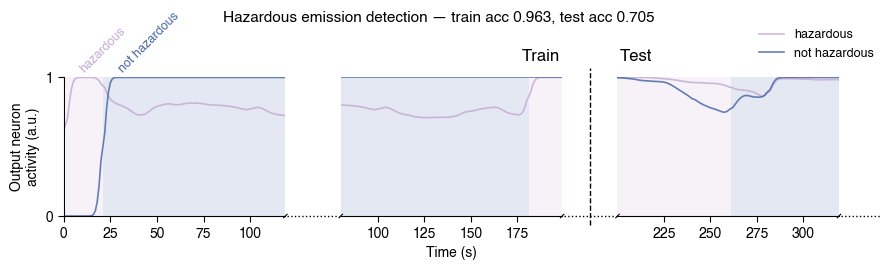

In [101]:
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from scipy.ndimage import gaussian_filter1d

# ── style (same as R2 - Online classification) ──
cm = ListedColormap(plt.rcParams['axes.prop_cycle'].by_key()['color'])
sigma            = 2.
max_len          = 20
connector_color  = 'black'
connector_lw     = 1.
connector_ls     = ':'
slash_color      = 'black'
slash_lw         = 0.8
slash_len_fig    = 0.02
slash_angle_deg  = 80
stub             = 0.04

# Three windows: early train, end of train, start of test.
top_intervals_idx = [(0, 6), (N_TRAIN_SEQ - 6, N_TRAIN_SEQ)]
j0, j1            = N_TRAIN_SEQ, N_TRAIN_SEQ + 6

# Frame-aligned class colour: 0 = unlabeled, 1 = hazardous, 2 = not hazardous.
colour = np.zeros_like(times_sec, dtype=int)
for i in range(len(sequence_sec)):
    t_start = sequence_sec[i]
    t_end   = sequence_sec[i + 1] if i + 1 < len(sequence_sec) else np.inf
    mask    = (times_sec >= t_start) & (times_sec < t_end)
    gas     = int(sequence[i][1])
    colour[mask] = 1 if gas in HAZARDOUS_GAS else 2

CLASS_COLOR = {1: cm(3), 2: cm(0)}     # 1 = hazardous (red), 2 = not hazardous (blue)


def seq_idx_window_to_sample_idx(a_idx, b_idx):
    a_idx = int(np.clip(a_idx, 0, len(sequence_sec) - 1))
    b_idx = int(np.clip(b_idx, 0, len(sequence_sec) - 1))
    t0 = int(np.abs(times_sec - sequence_sec[a_idx]).argmin())
    t1 = int(np.abs(times_sec - sequence_sec[b_idx]).argmin())
    if t1 <= t0:
        t1 = min(t0 + 1, len(times_sec))
    return t0, t1


def find_blocks(labels, max_len=20, ignore=0):
    labels = np.asarray(labels)
    n = len(labels)
    if n == 0:
        return []
    blocks, start, prev = [], 0, labels[0]
    for i in range(1, n + 1):
        cur = labels[i] if i < n else None
        if cur != prev:
            if prev != ignore:
                s = start
                while s < i:
                    e = min(s + max_len, i)
                    blocks.append((s, e, int(prev)))
                    s = e
            start, prev = i, cur
    return blocks


def block_edges_from_indices(x, s, e):
    L = x[0]  if s <= 0      else 0.5 * (x[s - 1] + x[s])
    R = x[-1] if e >= len(x) else 0.5 * (x[e - 1] + x[e])
    return L, R


t0_a, t1_a       = seq_idx_window_to_sample_idx(*top_intervals_idx[0])
t0_b, t1_b       = seq_idx_window_to_sample_idx(*top_intervals_idx[1])
t0_test, t1_test = seq_idx_window_to_sample_idx(j0, j1)
x0_ref = times_sec[t0_a]

# ── figure ──
fig = plt.figure(figsize=(10, 1.8))
gs  = GridSpec(1, 3, figure=fig, wspace=0.25)
ax_l = fig.add_subplot(gs[0, 0])
ax_m = fig.add_subplot(gs[0, 1])
ax_r = fig.add_subplot(gs[0, 2])

neuron_colors = [cm(3), cm(0)]   # neuron 0 = hazardous (red), 1 = not hazardous (blue)
neuron_labels = ['hazardous', 'not hazardous']


def plot_interval(ah, t0, t1, hide_y=False, title=None, pos=None):
    x = times_sec[t0:t1] - x0_ref
    labels_local = colour[t0:t1]
    blocks = find_blocks(labels_local, max_len=max_len)
    for n in range(z_out_online.shape[1]):
        smoothed = gaussian_filter1d(z_out_online[t0:t1, n], sigma=sigma)
        ah.plot(x, smoothed, label=neuron_labels[n],
                color=neuron_colors[n], linewidth=1.2, alpha=0.85)
    for s, e, lab in blocks:
        if lab == 0:
            continue
        L, R = block_edges_from_indices(x, s, e)
        if R > L:
            ah.axvspan(L, R, facecolor=CLASS_COLOR[lab], alpha=0.15, linewidth=0)
    ah.set_xlim(x[0], x[-1])
    ah.set_ylim(0., 1.)
    if hide_y:
        ah.set_yticks([])
        ah.spines['left'].set_visible(False)
    else:
        ah.set_yticks([0, 1])
    ah.spines[['top', 'right']].set_visible(False)
    if title:
        ah.text(0.99 if pos == 'right' else 0.01, 1.15, title,
                transform=ah.transAxes, va='center',
                ha='right' if pos == 'right' else 'left', fontsize=12)


plot_interval(ax_l, t0_a, t1_a)
plot_interval(ax_m, t0_b, t1_b, hide_y=True, title='Train', pos='right')
plot_interval(ax_r, t0_test, t1_test, hide_y=True, title='Test',  pos='left')


# ── class labels above first panel ──
def add_class_labels(ah, t0, t1, offset_frac=0.05, angle_deg=45):
    x = times_sec[t0:t1] - x0_ref
    labels_local = colour[t0:t1]
    blocks = find_blocks(labels_local, max_len=max_len)
    y0, y1 = ah.get_ylim()
    y_off = 0.02 * (y1 - y0)
    prev_lab = None
    for s, e, lab in blocks:
        if lab == 0 or lab == prev_lab:
            prev_lab = lab
            continue
        prev_lab = lab
        L, R = block_edges_from_indices(x, s, e)
        if R <= L:
            continue
        x_mid = 0.5 * (L + R)
        dx = offset_frac * (R - L)
        ah.text(x_mid + dx, y1 + y_off, CLASS_NAMES[lab - 1],
                color=CLASS_COLOR[lab],
                ha='left', va='bottom', fontsize=9,
                rotation=angle_deg, rotation_mode='anchor',
                transform=ah.transData, clip_on=False)


t0_labels, t1_labels = seq_idx_window_to_sample_idx(0, 3)
add_class_labels(ax_l, t0_labels, t1_labels)

ax_l.set_ylabel('Output neuron\nactivity (a.u.)')
ax_m.set_xlabel('Time (s)')

handles, labels_ = ax_l.get_legend_handles_labels()
ax_r.legend(handles, labels_, frameon=False, loc='lower center',
            bbox_to_anchor=(0.9, 1.05), ncol=1, fontsize=9)


# ── broken-axis slash connectors ──
def bottom_anchor_in_fig(ax, x_in_axes):
    pt_disp = ax.transAxes.transform((x_in_axes, 0.0))
    return fig.transFigure.inverted().transform(pt_disp)


pL_right = bottom_anchor_in_fig(ax_l, 1.0)
pM_left  = bottom_anchor_in_fig(ax_m, 0.0)
pM_right = bottom_anchor_in_fig(ax_m, 1.0)
pR_left  = bottom_anchor_in_fig(ax_r, 0.0)
pR_right = bottom_anchor_in_fig(ax_r, 1.0)

theta  = np.deg2rad(slash_angle_deg)
dx_fig = slash_len_fig * np.cos(theta)
dy_fig = slash_len_fig * np.sin(theta)


def draw_centered_slash(anchor_xy):
    xA, yA = anchor_xy
    fig.add_artist(Line2D([xA - dx_fig / 2, xA + dx_fig / 2],
                          [yA - dy_fig / 2, yA + dy_fig / 2],
                          transform=fig.transFigure, lw=slash_lw,
                          color=slash_color, clip_on=False))


def draw_gap(p_left, p_right):
    xL, yL = p_left
    xR, yR = p_right
    draw_centered_slash((xL, yL))
    draw_centered_slash((xR, yR))
    fig.add_artist(Line2D([xL + dx_fig / 2, xR - dx_fig / 2], [yL, yL],
                          transform=fig.transFigure, linestyle=connector_ls,
                          lw=connector_lw, color=connector_color, clip_on=False))


draw_gap(pL_right, pM_left)
draw_gap(pM_right, pR_left)

# trailing stub after the rightmost panel
xE, yE = pR_right
draw_centered_slash((xE, yE))
fig.add_artist(Line2D([xE + dx_fig / 2, xE + dx_fig / 2 + stub], [yE, yE],
                      transform=fig.transFigure, linestyle=connector_ls,
                      lw=connector_lw, color=connector_color, clip_on=False))


# ── train/test divider between middle and right panels ──
def axes_to_fig(ax, xy):
    return fig.transFigure.inverted().transform(ax.transAxes.transform(xy))


pM_bottom = axes_to_fig(ax_m, (0.0, 0.0))
pM_top    = axes_to_fig(ax_m, (0.0, 1.0))
pR_bottom = axes_to_fig(ax_r, (0.0, 0.0))
pR_top    = axes_to_fig(ax_r, (0.0, 1.0))

x_mid = 0.5 * (axes_to_fig(ax_m, (1.0, 0.0))[0] + axes_to_fig(ax_r, (0.0, 0.0))[0])
y_bot = min(pM_bottom[1], pR_bottom[1])
y_top = max(pM_top[1], pR_top[1])
fig.add_artist(Line2D([x_mid, x_mid], [y_bot - 0.05, y_top + 0.05],
                      transform=fig.transFigure, linestyle='--',
                      lw=connector_lw, color=connector_color, clip_on=False))

fig.suptitle(f'Hazardous emission detection — '
             f'train acc {acc_train:.3f}, test acc {acc_test:.3f}',
             y=1.25, fontsize=11)
plt.show()

## Threshold sweep on the hazardous-neuron activity

Treat detection as a binary decision on `z_out[:, 0]` (hazardous neuron):
`pred = positive (hazardous)` iff `z_out[:, 0] > θ`. Sweep θ on the training
set, pick the best, and report the accuracy on train and test.

best threshold (selected on train): θ = 0.9980
  training accuracy: 0.9632
  test     accuracy: 0.6828

train confusion matrix (rows = true, cols = pred; True=hazardous):
[[ 38   0]
 [  7 145]]

test confusion matrix (rows = true, cols = pred; True=hazardous):
[[ 326 3433]
 [ 120 7323]]


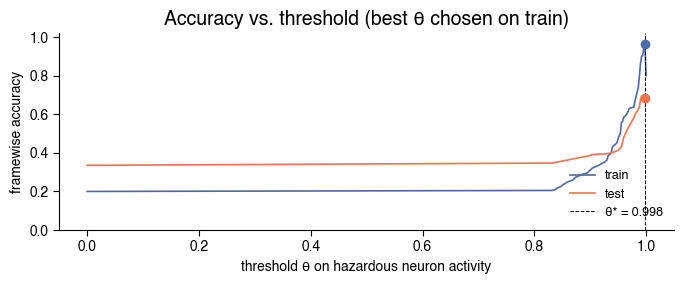

In [102]:
# Score = activity of the 'hazardous' output neuron (frozen W_out).
score    = z_out[:, 0]
y_pos    = (y_frame == 0)            # True if frame is hazardous

s_train  = score[train_mask]
s_test   = score[test_mask]
y_train  = y_pos[train_mask]
y_test   = y_pos[test_mask]

# Sweep candidate thresholds: every unique score in the train set, plus 0 and max.
thresholds = np.unique(np.concatenate(([0.0], s_train, [score.max() + 1e-6])))

acc_train_vs_thr = np.empty_like(thresholds)
acc_test_vs_thr  = np.empty_like(thresholds)
for i, thr in enumerate(thresholds):
    acc_train_vs_thr[i] = ((s_train > thr) == y_train).mean()
    acc_test_vs_thr[i]  = ((s_test  > thr) == y_test ).mean()

best_i   = int(np.argmax(acc_train_vs_thr))
best_thr = float(thresholds[best_i])
best_train = float(acc_train_vs_thr[best_i])
best_test  = float(acc_test_vs_thr[best_i])

print(f'best threshold (selected on train): θ = {best_thr:.4f}')
print(f'  training accuracy: {best_train:.4f}')
print(f'  test     accuracy: {best_test:.4f}')

# Confusion matrices at the best threshold.
for name, mask, s, y in [('train', train_mask, s_train, y_train),
                         ('test',  test_mask,  s_test,  y_test)]:
    p  = (s > best_thr)
    cm = np.array([[((y == a) & (p == b)).sum() for b in (True, False)]
                                                  for a in (True, False)])
    print(f'\n{name} confusion matrix (rows = true, cols = pred; True=hazardous):')
    print(cm)

# Accuracy-vs-threshold curve.
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(thresholds, acc_train_vs_thr, color='C0', lw=1.2, label='train')
ax.plot(thresholds, acc_test_vs_thr,  color='C1', lw=1.2, label='test')
ax.axvline(best_thr, color='k', lw=0.7, linestyle='--',
           label=f'θ* = {best_thr:.3f}')
ax.scatter([best_thr], [best_train], color='C0', zorder=5)
ax.scatter([best_thr], [best_test],  color='C1', zorder=5)
ax.set_xlabel('threshold θ on hazardous neuron activity')
ax.set_ylabel('framewise accuracy')
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Accuracy vs. threshold (best θ chosen on train)')
plt.tight_layout()
plt.show()